In [1]:
!pip install monai -q
!pip install albumentations -q

In [2]:
from pathlib import Path

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Config paths
# ============================================================

DATA_ROOT = Path(
    "/kaggle/input/datasets/triduongduc/dataset-for-caroitd-ultrasound-boundary/CUBS_Dataset"
)


# ============================================================
# Helper functions
# ============================================================

def get_image_id(mask_path: Path) -> str:
    """
    Example:
        tech_401_mask.png -> tech_401
    """
    return mask_path.stem.replace("_mask", "")


def read_ids(split_dir: Path):
    """
    Read image ids from masks folder.

    Example:
        split_dir = DATA_ROOT / "train"
        mask path = train/masks/tech_401_mask.png
        image id  = tech_401
    """
    image_dir = split_dir / "images"
    mask_dir = split_dir / "masks"

    ids = []

    for mask_path in sorted(mask_dir.glob("*_mask.png")):
        img_id = get_image_id(mask_path)

        img_path_tiff = image_dir / f"{img_id}.tiff"
        img_path_tif = image_dir / f"{img_id}.tif"
        img_path_png = image_dir / f"{img_id}.png"
        img_path_jpg = image_dir / f"{img_id}.jpg"

        if (
            img_path_tiff.exists()
            or img_path_tif.exists()
            or img_path_png.exists()
            or img_path_jpg.exists()
        ):
            ids.append(img_id)

    return ids


def find_image_path(image_dir: Path, img_id: str) -> Path:
    """
    Find image path by id with common extensions.
    """
    for ext in [".tiff", ".tif", ".png", ".jpg", ".jpeg"]:
        img_path = image_dir / f"{img_id}{ext}"
        if img_path.exists():
            return img_path

    raise FileNotFoundError(f"Image not found for id: {img_id} in {image_dir}")


# ============================================================
# Dataset
# ============================================================

class CUBSDataset(Dataset):
    def __init__(
        self,
        root_dir,
        split="train",
        image_ids=None,
        transform=None,
        return_id=False,
    ):
        """
        Dataset không crop ảnh/mask.

        Args:
            root_dir: path tới CUBS_Dataset
            split: train / val / test
            image_ids: list id ảnh. Nếu None thì tự đọc từ masks folder
            transform: Albumentations transform nếu có
            return_id: nếu True thì return thêm img_id
        """
        self.root_dir = Path(root_dir)
        self.split = split

        self.split_dir = self.root_dir / split
        self.image_dir = self.split_dir / "images"
        self.mask_dir = self.split_dir / "masks"

        self.transform = transform
        self.return_id = return_id

        if image_ids is None:
            self.image_ids = read_ids(self.split_dir)
        else:
            self.image_ids = image_ids

        if len(self.image_ids) == 0:
            raise ValueError(f"No valid image-mask pairs found in: {self.split_dir}")

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]

        img_path = find_image_path(self.image_dir, img_id)
        mask_path = self.mask_dir / f"{img_id}_mask.png"

        image = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise FileNotFoundError(f"Image not found or unreadable: {img_path}")

        if mask is None:
            raise FileNotFoundError(f"Mask not found or unreadable: {mask_path}")

        # Không crop nữa, chỉ nhị phân hóa mask
        mask = (mask > 127).astype(np.uint8)

        # Albumentations transform nếu có
        if self.transform is not None:
            out = self.transform(image=image, mask=mask)
            image = out["image"]
            mask = out["mask"]

        # Nếu transform chưa convert sang tensor
        if not isinstance(image, torch.Tensor):
            image = image.astype(np.float32) / 255.0
            image = torch.from_numpy(image).unsqueeze(0)  # [1, H, W]

        if not isinstance(mask, torch.Tensor):
            mask = torch.from_numpy(mask).long()          # [H, W]
        else:
            mask = mask.long()

        if self.return_id:
            return image, mask, img_id

        return image, mask

In [3]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    # ── 1. Resize & Pad ──────────────────────────────────────────
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(
        min_height=512, min_width=512,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    ),

    # ── 2. Geometric (nhẹ - carotid có hướng giải phẫu) ─────────
    A.HorizontalFlip(p=0.5),                    # chụp trái/phải cổ

    A.ShiftScaleRotate(
        shift_limit=0.08,   # ±8%  
        scale_limit=0.10,   # ±15%
        rotate_limit=15,    # ±15° 
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.5,
    ),

    # Elastic – giả lập lực ép đầu dò lên mô mềm (biên dạng nhẹ)
    A.ElasticTransform(
        alpha=150, sigma=8,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
        p=0.6,
    ),

    # ── 3. Ultrasound artifact ───────────────────────────────────
    A.GaussianBlur(blur_limit=(3, 5)),      # depth-of-field blur

    # ── 4. Intensity – giả lập Gain / TGC / preset máy ──────────
    A.RandomBrightnessContrast(
        brightness_limit=0.15,
        contrast_limit=0.15,
        p=0.2,
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.2),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),

    # ── 5. Normalize & Tensor ────────────────────────────────────
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])


val_transform = A.Compose([
    A.LongestMaxSize(max_size=512),
    A.PadIfNeeded(
        min_height=512, min_width=512,
        border_mode=cv2.BORDER_CONSTANT, fill=0, fill_mask=0,
    ),
    A.Normalize(normalization="min_max"),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
batch_size  = 8

train_dataset = CUBSDataset(
    root_dir=DATA_ROOT,
    split="train",
    transform=train_transform,
    return_id=False,
)

val_dataset = CUBSDataset(
    root_dir=DATA_ROOT,
    split="val",
    transform=val_transform,
    return_id=False,
)

test_dataset = CUBSDataset(
    root_dir=DATA_ROOT,
    split="test",
    transform=val_transform,
    return_id=True,
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
)

In [5]:
print(f"train={len(train_dataset)} | val={len(val_dataset)} |  test={len(test_dataset)}")

train=638 | val=183 |  test=100


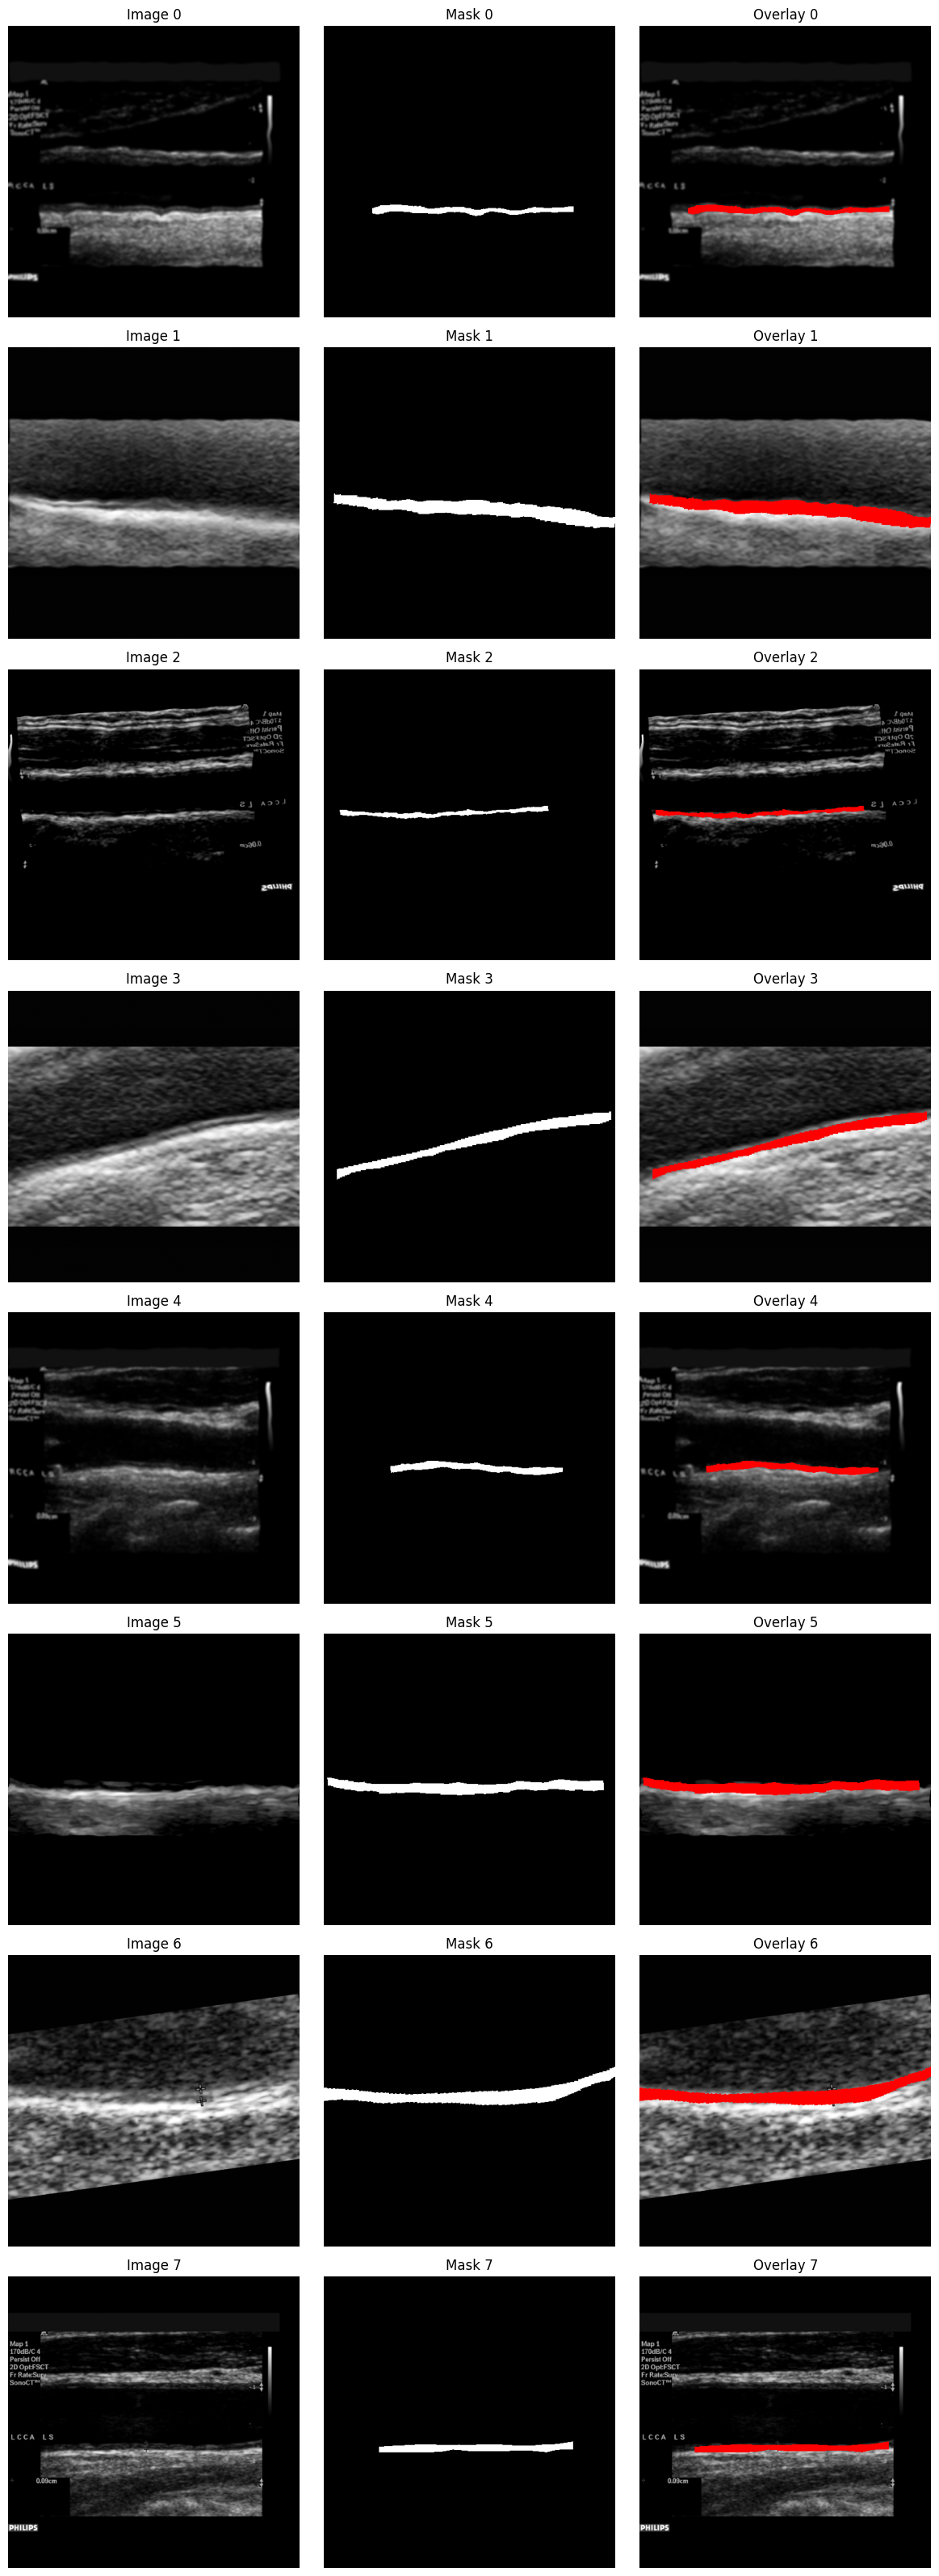

In [6]:
import matplotlib.pyplot as plt
import torch
import numpy as np


def to_numpy_image(x):
    """
    Convert image tensor/numpy về dạng H x W để hiển thị.
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()

        if x.ndim == 3:
            # C x H x W -> H x W
            if x.shape[0] == 1:
                x = x.squeeze(0)
            else:
                x = x.permute(1, 2, 0)

        x = x.numpy()

    x = np.asarray(x)

    if x.max() <= 1.0:
        x = x * 255.0

    return x.astype(np.uint8)


def to_numpy_mask(y):
    """
    Convert mask tensor/numpy về dạng H x W.
    """
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu()

        if y.ndim == 3:
            y = y.squeeze(0)

        y = y.numpy()

    return np.asarray(y).astype(np.uint8)


def visualize_train_loader(train_loader, num_images=4):
    """
    Trực quan hóa image, mask và overlay từ train_loader.
    """
    images, masks = next(iter(train_loader))

    num_images = min(num_images, len(images))

    plt.figure(figsize=(12, num_images * 4))

    for i in range(num_images):
        image = to_numpy_image(images[i])
        mask = to_numpy_mask(masks[i])

        overlay = np.stack([image, image, image], axis=-1)
        overlay[mask > 0] = [255, 0, 0]

        plt.subplot(num_images, 3, i * 3 + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"Image {i}")
        plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Mask {i}")
        plt.axis("off")

        plt.subplot(num_images, 3, i * 3 + 3)
        plt.imshow(overlay)
        plt.title(f"Overlay {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


visualize_train_loader(train_loader, num_images=8)

In [7]:
def check_val_loader(val_loader, num_batches=3):
    print("===== CHECK VAL LOADER =====")

    for batch_idx, (images, masks) in enumerate(val_loader):
        print(f"\nBatch {batch_idx + 1}")

        print("images shape:", images.shape)
        print("masks shape :", masks.shape)

        print("images dtype:", images.dtype)
        print("masks dtype :", masks.dtype)

        print("images min :", images.min().item())
        print("images max :", images.max().item())

        print("masks min  :", masks.min().item())
        print("masks max  :", masks.max().item())

        print("mask unique values:", torch.unique(masks))

        if batch_idx + 1 >= num_batches:
            break

check_val_loader(val_loader, num_batches=3)

===== CHECK VAL LOADER =====

Batch 1
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.int64
images min : 0.0
images max : 0.999999607843291
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1])

Batch 2
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.int64
images min : 0.0
images max : 0.9999996062993676
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1])

Batch 3
images shape: torch.Size([8, 1, 512, 512])
masks shape : torch.Size([8, 512, 512])
images dtype: torch.float64
masks dtype : torch.int64
images min : 0.0
images max : 0.9999996062993676
masks min  : 0
masks max  : 1
mask unique values: tensor([0, 1])


In [8]:
from monai.metrics.meandice import DiceMetric
from monai.metrics.meaniou import MeanIoU
from monai.losses.dice import DiceCELoss
from monai.metrics import HausdorffDistanceMetric

from torch import nn
from torch.optim.adamw import AdamW

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-30 12:52:14.140682: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777553534.163255     423 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777553534.170745     423 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777553534.190752     423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777553534.190774     423 computation_placer.cc:1

In [9]:
from monai.networks.nets.swin_unetr import SwinUNETR
model = SwinUNETR(
    in_channels=1,
    out_channels=2,
    depths=(2, 2, 6, 2),
    num_heads=(3, 6, 12, 24),
    feature_size=48,
    norm_name="instance",
    drop_rate=0.0,
    attn_drop_rate=0.0,
    use_checkpoint=False,
    spatial_dims=2,
    patch_norm = True,
    use_v2= True,
)


criterion = DiceCELoss(
        include_background=True,
        to_onehot_y=True,
        softmax=True,        # cho multi-class với softmax
        lambda_dice=2.0,
        lambda_ce=1.0,
        jaccard = True,
    )

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10,
    threshold=1e-4,
    cooldown=0,
    min_lr=2e-6,
)

dice_metric = DiceMetric(include_background=False, reduction="mean")
iou_metric  = MeanIoU(include_background=False, reduction="mean")
hd95_metric = HausdorffDistanceMetric(
    include_background=False,
    percentile=95,
    directed=False,
    reduction="mean",
    get_not_nans=False,
)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device using:", device)

Device using: cuda


In [11]:
from typing import Tuple, Dict, Any, List
from pathlib import Path
import csv
import math

import torch
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from tabulate import tabulate
from tqdm import tqdm


# ============================================================
# Utils
# ============================================================

def unwrap_logits(outputs: torch.Tensor) -> torch.Tensor:
    """
    Compatible with:
    - SwinUNETR: returns Tensor [B, C, H, W]
    - UNet++ / deep supervision: may return list/tuple
    - Dict-style outputs: optional support
    """
    if isinstance(outputs, (list, tuple)):
        outputs = outputs[0]

    if isinstance(outputs, dict):
        for key in ["logits", "out", "output"]:
            if key in outputs:
                outputs = outputs[key]
                break

    if not torch.is_tensor(outputs):
        raise TypeError(f"Model output must be Tensor/list/tuple/dict, got {type(outputs)}")

    if outputs.dim() != 4:
        raise ValueError(
            f"Logits must have shape [B, C, H, W], got {tuple(outputs.shape)}. "
            "This usually means you used outputs[0] on SwinUNETR and removed batch dimension."
        )

    return outputs


def to_onehot(labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    """
    labels:
      [B, H, W] or [B, 1, H, W]
    return:
      [B, C, H, W]
    """
    if labels.dim() == 4:
        labels = labels.squeeze(1)

    return F.one_hot(labels.long(), num_classes).permute(0, 3, 1, 2).float()


def ensure_mask_shape(masks: torch.Tensor) -> torch.Tensor:
    """
    MONAI DiceCELoss(to_onehot_y=True) expects target [B, 1, H, W].
    """
    if masks.dim() == 3:
        masks = masks.unsqueeze(1)
    return masks.long()


def metric_scalar(val) -> float:
    if isinstance(val, (list, tuple)):
        val = val[0]

    if torch.is_tensor(val):
        val = val.detach().float()
        val = val[torch.isfinite(val)]
        if val.numel() == 0:
            return float("nan")
        return float(val.mean().item())

    try:
        val = float(val)
        return val if math.isfinite(val) else float("nan")
    except Exception:
        return float("nan")


def get_lr(optimizer: torch.optim.Optimizer) -> float:
    return float(optimizer.param_groups[0]["lr"])


def onehot_pair(logits: torch.Tensor, masks: torch.Tensor, num_classes: int):
    pred = torch.argmax(logits, dim=1)       # [B, H, W]
    gt = masks.squeeze(1)                    # [B, H, W]
    pred_oh = to_onehot(pred, num_classes)   # [B, C, H, W]
    gt_oh = to_onehot(gt, num_classes)       # [B, C, H, W]
    return pred_oh, gt_oh


def safe_hd95(val: float, fallback: float = 1e6) -> float:
    if val is None:
        return fallback
    if not math.isfinite(float(val)):
        return fallback
    return float(val)


def checkpoint_score(
    val_dice: float,
    val_hd95: float,
    hd95_weight: float = 0.003,
    hd95_clip: float = 100.0,
) -> float:
    """
    Main best-model score.

    Higher is better.

    Pure Dice can select bad-boundary models.
    This score rewards Dice but penalizes HD95.

    Example:
      Dice = 0.88, HD95 = 5   -> score = 0.865
      Dice = 0.89, HD95 = 50  -> score = 0.740

    You can tune hd95_weight:
      0.001 = weak HD95 penalty
      0.003 = balanced
      0.005 = stronger HD95 penalty
    """
    h = safe_hd95(val_hd95, fallback=hd95_clip)
    h = min(max(h, 0.0), hd95_clip)
    return float(val_dice - hd95_weight * h)


def save_checkpoint(
    path: str,
    model,
    optimizer,
    scheduler,
    epoch: int,
    metrics: Dict[str, float],
    model_name: str = "SwinUNETR",
):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    ckpt = {
        "epoch": epoch,
        "model_name": model_name,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state": scheduler.state_dict() if scheduler is not None else None,
        "metrics": metrics,
    }

    torch.save(ckpt, path)


def save_epoch_to_csv(row: dict, csv_path: str):
    p = Path(csv_path)
    p.parent.mkdir(parents=True, exist_ok=True)

    write_header = not p.exists()

    with open(p, mode="a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=list(row.keys()))
        if write_header:
            writer.writeheader()
        writer.writerow(row)


def step_scheduler(scheduler, monitor_value: float):
    if scheduler is None:
        return

    try:
        scheduler.step(monitor_value)
    except TypeError:
        scheduler.step()


# ============================================================
# Train one epoch
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    num_classes: int,
    dice_metric,
    iou_metric,
    epoch: int,
    num_epochs: int,
    device,
    use_amp: bool = True,
    scaler=None,
) -> Tuple[float, float, float]:

    device_type = device.type
    amp_enabled = use_amp and device_type == "cuda"

    model.train()
    dice_metric.reset()
    iou_metric.reset()

    if scaler is None and amp_enabled:
        scaler = GradScaler(device_type, enabled=True)

    running_loss = 0.0
    bar = tqdm(loader, desc=f"Epoch [{epoch}/{num_epochs}] Train", leave=False)

    for images, masks in bar:
        images = images.to(device, non_blocking=True).float()
        masks = ensure_mask_shape(masks.to(device, non_blocking=True))

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device_type, enabled=amp_enabled):
            outputs = model(images)
            logits = unwrap_logits(outputs)

            # For MONAI DiceCELoss(to_onehot_y=True, softmax=True)
            # logits: [B, C, H, W]
            # masks : [B, 1, H, W]
            loss = criterion(logits, masks)

        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += float(loss.item())

        with torch.no_grad():
            pred_oh, mask_oh = onehot_pair(logits, masks, num_classes)
            dice_metric(pred_oh, mask_oh)
            iou_metric(pred_oh, mask_oh)

        bar.set_postfix(
            loss=f"{loss.item():.4f}",
            lr=f"{get_lr(optimizer):.2e}",
        )

    avg_loss = running_loss / max(len(loader), 1)
    train_dice = metric_scalar(dice_metric.aggregate())
    train_iou = metric_scalar(iou_metric.aggregate())

    return avg_loss, train_dice, train_iou


# ============================================================
# Validation one epoch
# ============================================================

def val_one_epoch(
    model,
    loader,
    criterion,
    num_classes: int,
    dice_metric,
    iou_metric,
    hd95_metric,
    epoch: int,
    num_epochs: int,
    device,
    use_amp: bool = True,
) -> Tuple[float, float, float, float]:

    device_type = device.type
    amp_enabled = use_amp and device_type == "cuda"

    model.eval()
    dice_metric.reset()
    iou_metric.reset()
    hd95_metric.reset()

    running_loss = 0.0
    bar = tqdm(loader, desc=f"Epoch [{epoch}/{num_epochs}] Val", leave=False)

    with torch.no_grad():
        for images, masks in bar:
            images = images.to(device, non_blocking=True).float()
            masks = ensure_mask_shape(masks.to(device, non_blocking=True))

            with autocast(device_type=device_type, enabled=amp_enabled):
                outputs = model(images)
                logits = unwrap_logits(outputs)
                loss = criterion(logits, masks)

            running_loss += float(loss.item())

            pred_oh, mask_oh = onehot_pair(logits, masks, num_classes)

            dice_metric(pred_oh, mask_oh)
            iou_metric(pred_oh, mask_oh)

            # HD95 can be memory-heavy; CPU is safer.
            hd95_metric(pred_oh.cpu(), mask_oh.cpu())

            bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = running_loss / max(len(loader), 1)
    val_dice = metric_scalar(dice_metric.aggregate())
    val_iou = metric_scalar(iou_metric.aggregate())
    val_hd95 = metric_scalar(hd95_metric.aggregate())

    return avg_loss, val_dice, val_iou, val_hd95


# ============================================================
# Full training loop
# ============================================================

def fit(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler,
    dice_metric,
    iou_metric,
    hd95_metric,
    num_classes: int,
    num_epochs: int,
    device,
    use_amp: bool = True,
    save_dir: str = "./checkpoints_swinunetr",
    csv_path: str = "./training_history.csv",

    # Best model policy
    hd95_weight: float = 0.003,
    hd95_clip: float = 100.0,
    min_dice_for_best_hd95: float = 0.80,
) -> Dict[str, Any]:

    model = model.to(device)

    amp_enabled = use_amp and device.type == "cuda"
    scaler = GradScaler(device.type, enabled=amp_enabled) if amp_enabled else None

    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    best_score = -1e18
    best_val_dice = -1e18
    best_val_hd95 = 1e18

    history: List[Dict[str, float]] = []

    headers = [
        "epoch", "lr",
        "train_loss", "train_dice", "train_iou",
        "val_loss", "val_dice", "val_iou", "val_hd95",
        "score", "saved"
    ]

    for epoch in range(1, num_epochs + 1):
        train_loss, train_dice, train_iou = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            num_classes=num_classes,
            dice_metric=dice_metric,
            iou_metric=iou_metric,
            epoch=epoch,
            num_epochs=num_epochs,
            device=device,
            use_amp=use_amp,
            scaler=scaler,
        )

        val_loss, val_dice, val_iou, val_hd95 = val_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            num_classes=num_classes,
            dice_metric=dice_metric,
            iou_metric=iou_metric,
            hd95_metric=hd95_metric,
            epoch=epoch,
            num_epochs=num_epochs,
            device=device,
            use_amp=use_amp,
        )

        val_score = checkpoint_score(
            val_dice=val_dice,
            val_hd95=val_hd95,
            hd95_weight=hd95_weight,
            hd95_clip=hd95_clip,
        )

        # Use score for ReduceLROnPlateau if scheduler is mode="max".
        # If your scheduler is StepLR/CosineAnnealingLR, this still works.
        step_scheduler(scheduler, val_score)

        metrics = {
            "epoch": epoch,
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_hd95": val_hd95,
            "val_score": val_score,
            "lr": get_lr(optimizer),
        }

        saved_tags = []

        # 1. Always save last checkpoint
        save_checkpoint(
            path=save_dir / "last.pt",
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch,
            metrics=metrics,
            model_name="SwinUNETR",
        )

        # 2. Main best: Dice - HD95 penalty
        # Recommended checkpoint for your case.
        if val_score > best_score:
            best_score = val_score
            save_checkpoint(
                path=save_dir / "best_score.pt",
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                metrics=metrics,
                model_name="SwinUNETR",
            )
            saved_tags.append("best_score")

        # 3. Pure best Dice
        # Saved only for comparison, not always the best boundary model.
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            save_checkpoint(
                path=save_dir / "best_dice.pt",
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                metrics=metrics,
                model_name="SwinUNETR",
            )
            saved_tags.append("best_dice")

        # 4. Best HD95 with Dice gate
        # Avoid choosing a model with low HD95 but poor segmentation.
        h = safe_hd95(val_hd95, fallback=1e18)
        if val_dice >= min_dice_for_best_hd95 and h < best_val_hd95:
            best_val_hd95 = h
            save_checkpoint(
                path=save_dir / "best_hd95.pt",
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                epoch=epoch,
                metrics=metrics,
                model_name="SwinUNETR",
            )
            saved_tags.append("best_hd95")

        row = {
            "epoch": epoch,
            "lr": get_lr(optimizer),
            "train_loss": train_loss,
            "train_dice": train_dice,
            "train_iou": train_iou,
            "val_loss": val_loss,
            "val_dice": val_dice,
            "val_iou": val_iou,
            "val_hd95": val_hd95,
            "val_score": val_score,
            "best_score": best_score,
            "best_val_dice": best_val_dice,
            "best_val_hd95": best_val_hd95,
            "saved": "|".join(saved_tags),
        }

        history.append(row)
        save_epoch_to_csv(row, csv_path)

        print(tabulate(
            [[
                epoch,
                f"{row['lr']:.2e}",
                f"{train_loss:.4f}",
                f"{train_dice:.4f}",
                f"{train_iou:.4f}",
                f"{val_loss:.4f}",
                f"{val_dice:.4f}",
                f"{val_iou:.4f}",
                f"{val_hd95:.4f}",
                f"{val_score:.4f}",
                row["saved"],
            ]],
            headers=headers,
            tablefmt="github",
        ))

    return {
        "best_score": best_score,
        "best_val_dice": best_val_dice,
        "best_val_hd95": best_val_hd95,
        "history": history,
        "save_dir": str(save_dir),
        "best_score_path": str(save_dir / "best_score.pt"),
        "best_dice_path": str(save_dir / "best_dice.pt"),
        "best_hd95_path": str(save_dir / "best_hd95.pt"),
        "last_path": str(save_dir / "last.pt"),
    }

In [12]:
# ckpt  = torch.load("/kaggle/working/checkpoints_swinunetr/best_score.pt", map_location="cpu", weights_only=False)
# state = ckpt["model_state"]
# model.load_state_dict(state, strict=True)

In [ ]:
result = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    dice_metric=dice_metric,
    iou_metric=iou_metric,
    hd95_metric=hd95_metric,
    num_classes=2,
    num_epochs=100,
    device=device,
    use_amp=True,
    save_dir="./checkpoints_swinunetr",
    csv_path="./logs/swinunetr_training_history.csv",

    # Nếu Dice tốt nhưng HD95 hay tệ, tăng hd95_weight lên 0.004 hoặc 0.005
    hd95_weight=0.003,
    hd95_clip=100.0,
    min_dice_for_best_hd95=0.80,
)

Epoch [1/100] Val:   0%|          | 0/23 [00:00<?, ?it/s]                                     /usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)
/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:221: FutureWarning: monai.metrics.utils get_mask_edges:always_return_as_numpy: Argument `always_return_as_numpy` has been deprecated since version 1.5.0. It will be removed in version 1.7.0. The option is removed and the return type will always be equal to the input type.
  warn_deprecated(argname, msg, warning_category)


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved                |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|----------------------|
|       1 | 0.0001 |       1.3781 |       0.5457 |      0.4142 |     1.0989 |     0.7314 |     0.589 |    44.5939 |  0.5976 | best_score|best_dice |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved                |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|----------------------|
|       2 | 0.0001 |       1.0315 |       0.7397 |      0.6002 |     0.9547 |     0.7731 |    0.6409 |    25.5339 |  0.6965 | best_score|best_dice |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved                |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|----------------------|
|       3 | 0.0001 |       0.9164 |        0.762 |      0.6276 |     0.8565 |     0.7808 |    0.6506 |    18.9423 |   0.724 | best_score|best_dice |


|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved                |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|----------------------|
|       4 | 0.0001 |       0.8233 |       0.7654 |      0.6325 |      0.758 |     0.7987 |    0.6731 |    20.5067 |  0.7372 | best_score|best_dice |


...

|   epoch |     lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved   |
|---------|--------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|---------|
|      48 | 0.0001 |       0.3157 |       0.8398 |      0.7279 |     0.3439 |     0.8213 |    0.7039 |    14.4856 |  0.7778 |         |


|   epoch |    lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved   |
|---------|-------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|---------|
|      49 | 5e-05 |        0.317 |       0.8386 |      0.7265 |      0.348 |     0.8189 |    0.7003 |    15.5842 |  0.7721 |         |


|   epoch |    lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved   |
|---------|-------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|---------|
|      50 | 5e-05 |       0.3088 |       0.8437 |      0.7336 |     0.3406 |     0.8225 |    0.7057 |    13.7712 |  0.7811 |         |


|   epoch |    lr |   train_loss |   train_dice |   train_iou |   val_loss |   val_dice |   val_iou |   val_hd95 |   score | saved   |
|---------|-------|--------------|--------------|-------------|------------|------------|-----------|------------|---------|---------|
|      51 | 5e-05 |       0.3058 |       0.8452 |      0.7357 |     0.3409 |     0.8229 |    0.7062 |    13.9105 |  0.7812 |         |


Epoch [52/100] Train:  92%|█████████▎| 74/80 [01:43<00:08,  1.38s/it, loss=0.3141, lr=5.00e-05]